# Product & UX Analytics – Google Merchandise Store

## Objetivo del análisis

El objetivo de este proyecto es analizar el comportamiento de los usuarios de un e-commerce a partir de eventos de Google Analytics 4, con el fin de identificar:

- patrones de navegación;
- pérdidas dentro del funnel de conversión;
- diferencias de comportamiento según dispositivo;
- diferencias según fuente de tráfico;
- productos con alto interés pero baja conversión;
- comportamiento de retención;
- diferencias entre cohortes de usuarios.

El análisis busca generar insights que puedan apoyar decisiones de producto, experiencia de usuario y adquisición.

Los datos fueron extraídos desde el dataset público de Google Merchandise Store disponible en BigQuery.

El periodo analizado corresponde a:

**1 de noviembre de 2020 – 31 de enero de 2021.**

El proyecto combina:

- SQL y BigQuery para extracción y agregación;
- Python y Pandas para análisis;
- Matplotlib para visualización;
- análisis estadístico para validación de hipótesis;
- Power BI para la presentación final de resultados.

## 1. Carga y validación

Se cargan los resultados agregados obtenidos en BigQuery y se verifica que los archivos estén disponibles y sin problemas evidentes de estructura.

In [ ]:
from google.colab import drive
from pathlib import Path
import shutil
import pandas as pd

# Montar Google Drive
drive.mount("/content/drive")

# Carpetas
TEMP_DIR = Path("/content")
DATA_DIR = Path("/content/drive/MyDrive/product-ux-analytics/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Archivos requeridos
files = [
    "funnel_general.csv",
    "funnel_device.csv",
    "traffic_sources.csv",
    "product_anomalies.csv",
    "retention_days.csv",
    "cohort_retention.csv"
]

# Guardar en Drive si están en /content
missing = []

for file in files:
    temp_file = TEMP_DIR / file
    drive_file = DATA_DIR / file

    if temp_file.exists():
        shutil.copy2(temp_file, drive_file)
        print(f"Guardado en Drive: {file}")
    elif drive_file.exists():
        print(f"Ya existe en Drive: {file}")
    else:
        print(f"FALTA: {file}")
        missing.append(file)

if missing:
    raise FileNotFoundError(
        "Faltan estos archivos: " + ", ".join(missing)
    )

# Cargar datasets
funnel = pd.read_csv(DATA_DIR / "funnel_general.csv")
devices = pd.read_csv(DATA_DIR / "funnel_device.csv")
traffic = pd.read_csv(DATA_DIR / "traffic_sources.csv")
products = pd.read_csv(DATA_DIR / "product_anomalies.csv")
retention = pd.read_csv(DATA_DIR / "retention_days.csv")
cohorts = pd.read_csv(DATA_DIR / "cohort_retention.csv")

print("\nTodos los CSV están guardados y cargados correctamente.")
print(f"Ubicación permanente: {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Guardado en Drive: funnel_general.csv
Guardado en Drive: funnel_device.csv
Guardado en Drive: traffic_sources.csv
Guardado en Drive: product_anomalies.csv
Guardado en Drive: retention_days.csv
Guardado en Drive: cohort_retention.csv

Todos los CSV están guardados y cargados correctamente.
Ubicación permanente: /content/drive/MyDrive/product-ux-analytics/data


## 2. Funnel de conversión

Se analiza el recorrido `Product View → Add to Cart → Checkout → Purchase` para localizar las etapas con mayor pérdida de usuarios.

,source_name,view_item_users,add_to_cart_users,checkout_users,purchase_users,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,overall_conversion_rate
0,(data deleted),4924,1349,1124,680,27.40,83.32,60.50,13.81
1,shop.googlemerchandisestore.com,6180,1392,1091,568,22.52,78.38,52.06,9.19
2,(direct),16492,3338,2430,1054,20.24,72.80,43.37,6.39
3,<Other>,19201,3718,2643,1063,19.36,71.09,40.22,5.54
4,google,25105,4672,3438,1377,18.61,73.59,40.05,5.48


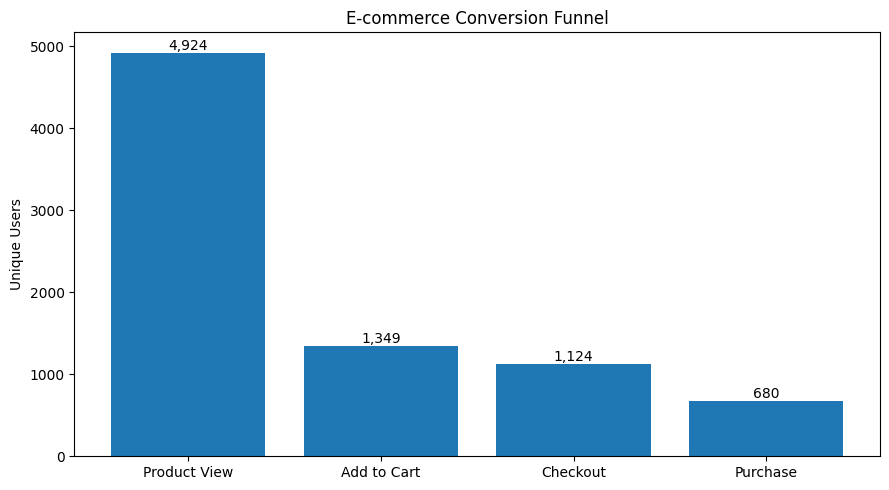

In [ ]:
display(funnel)

stages = ["Product View", "Add to Cart", "Checkout", "Purchase"]
users = [
    funnel.loc[0, "view_item_users"],
    funnel.loc[0, "add_to_cart_users"],
    funnel.loc[0, "checkout_users"],
    funnel.loc[0, "purchase_users"],
]

plt.figure(figsize=(9, 5))
plt.bar(stages, users)
plt.title("E-commerce Conversion Funnel")
plt.ylabel("Unique Users")

for i, value in enumerate(users):
    plt.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

,stage,conversion_rate,dropoff_rate
0,View → Cart,27.40,72.60
1,Cart → Checkout,83.32,16.68
2,Checkout → Purchase,60.50,39.50


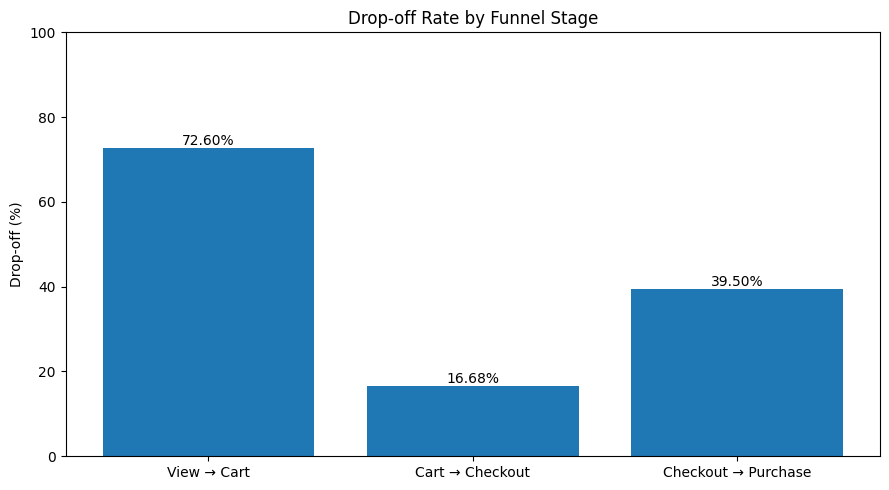

Insight: la conversión general es 13.81%. El mayor abandono ocurre en View → Cart (72.60%).


In [ ]:
funnel_metrics = pd.DataFrame({
    "stage": [
        "View → Cart",
        "Cart → Checkout",
        "Checkout → Purchase",
    ],
    "conversion_rate": [
        funnel.loc[0, "view_to_cart_rate"],
        funnel.loc[0, "cart_to_checkout_rate"],
        funnel.loc[0, "checkout_to_purchase_rate"],
    ],
})

funnel_metrics["dropoff_rate"] = 100 - funnel_metrics["conversion_rate"]
display(funnel_metrics)

plt.figure(figsize=(9, 5))
plt.bar(funnel_metrics["stage"], funnel_metrics["dropoff_rate"])
plt.title("Drop-off Rate by Funnel Stage")
plt.ylabel("Drop-off (%)")
plt.ylim(0, 100)

for i, value in enumerate(funnel_metrics["dropoff_rate"]):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

largest = funnel_metrics.loc[funnel_metrics["dropoff_rate"].idxmax()]
overall = funnel.loc[0, "overall_conversion_rate"]

print(
    f"Insight: la conversión general es {overall:.2f}%. "
    f"El mayor abandono ocurre en {largest['stage']} "
    f"({largest['dropoff_rate']:.2f}%)."
)

## 3. Conversión por dispositivo

Se compara el rendimiento de Mobile, Desktop y Tablet para evaluar si existen diferencias relevantes en el funnel.

,device_category,view_item_users,add_to_cart_users,checkout_users,purchase_users,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,overall_conversion_rate
0,mobile,24810,5142,3968,1851,20.73,77.17,46.65,7.46
1,desktop,36323,7384,5665,2541,20.33,76.72,44.85,7.00
2,tablet,1443,276,219,97,19.13,79.35,44.29,6.72


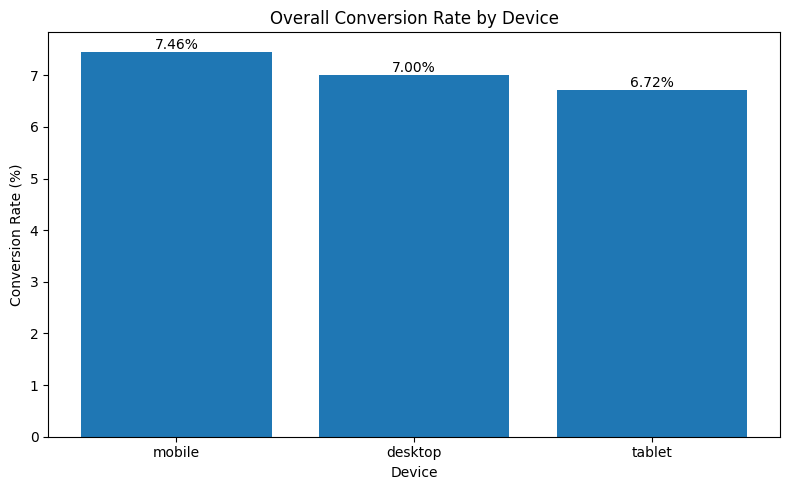

Insight: mobile presenta la mayor conversión (7.46%), frente a tablet (6.72%).


In [ ]:
display(devices)

device_plot = devices.sort_values("overall_conversion_rate", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(
    device_plot["device_category"],
    device_plot["overall_conversion_rate"],
)
plt.title("Overall Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate (%)")

for i, value in enumerate(device_plot["overall_conversion_rate"]):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

best_device = device_plot.iloc[0]
worst_device = device_plot.iloc[-1]

print(
    f"Insight: {best_device['device_category']} presenta la mayor conversión "
    f"({best_device['overall_conversion_rate']:.2f}%), frente a "
    f"{worst_device['device_category']} "
    f"({worst_device['overall_conversion_rate']:.2f}%)."
)

### Nota metodológica sobre significancia estadística

Los archivos disponibles contienen **conteos agregados de usuarios por evento**, no un funnel secuencial por sesión donde se garantice que cada compra pertenece al mismo conjunto de usuarios que inició en `view_item`.

Por esta razón, este notebook mantiene la comparación por dispositivo como **análisis descriptivo** y no presenta una prueba de significancia como evidencia causal o inferencial. Una prueba formal debería construirse a partir de datos a nivel usuario/sesión y una definición estricta del funnel.

## 4. Fuentes de tráfico

Se compara volumen y conversión por fuente de adquisición para identificar canales que generan tráfico pero no necesariamente usuarios con alta intención de compra.

,source_name,view_item_users,purchase_users,view_to_cart_rate,overall_conversion_rate
4,google,25105,1377,18.61,5.48
3,<Other>,19201,1063,19.36,5.54
2,(direct),16492,1054,20.24,6.39
1,shop.googlemerchandisestore.com,6180,568,22.52,9.19
0,(data deleted),4924,680,27.40,13.81


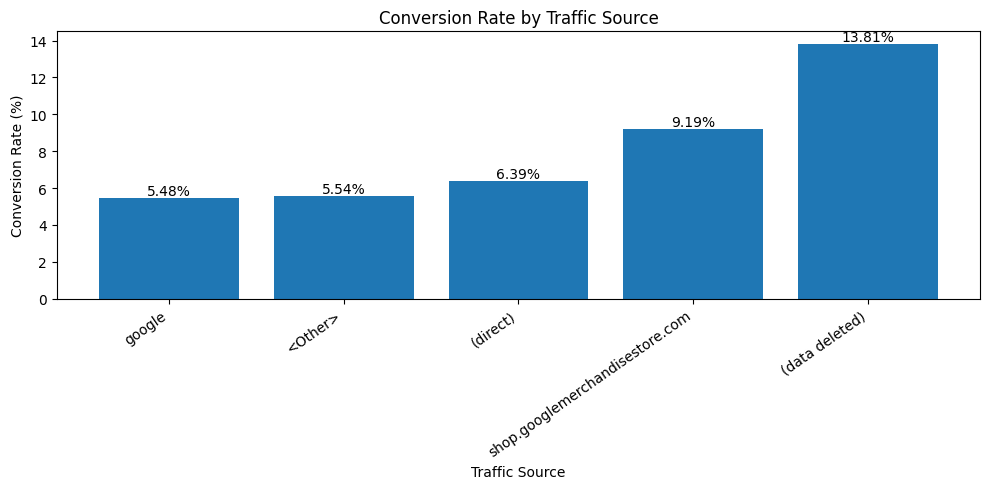

Insight: la fuente con mayor volumen es google con 25,105 usuarios que visualizaron productos y una conversión de 5.48%.


In [ ]:
traffic_ranked = traffic.sort_values(
    ["view_item_users", "overall_conversion_rate"],
    ascending=[False, False],
).copy()

display(
    traffic_ranked[
        [
            "source_name",
            "view_item_users",
            "purchase_users",
            "view_to_cart_rate",
            "overall_conversion_rate",
        ]
    ]
)

plt.figure(figsize=(10, 5))
plt.bar(
    traffic_ranked["source_name"],
    traffic_ranked["overall_conversion_rate"],
)
plt.title("Conversion Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=35, ha="right")

for i, value in enumerate(traffic_ranked["overall_conversion_rate"]):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

highest_volume = traffic_ranked.loc[traffic_ranked["view_item_users"].idxmax()]
print(
    f"Insight: la fuente con mayor volumen es {highest_volume['source_name']} "
    f"con {highest_volume['view_item_users']:,.0f} usuarios que visualizaron productos "
    f"y una conversión de {highest_volume['overall_conversion_rate']:.2f}%."
)

## 5. Productos con comportamiento anómalo

El dataset `product_anomalies.csv` contiene productos con:
- al menos 1.000 viewers;
- `View → Cart ≥ 20%`;
- conversión final `≤ 1%`.

Se priorizan los casos con alto interés inicial pero pocas o ninguna compra registrada.

,item_name,viewers,cart_users,buyers,avg_price,units_purchased,revenue,view_to_cart_rate,conversion_rate
0,Google Navy Speckled Tee,13696,3527,129,29.96,178,4440.0,25.75,0.94
1,Google Campus Bike Eco Tee Navy,11339,3063,41,24.97,56,1165.0,27.01,0.36
2,Google Land & Sea Cotton Cap,10796,3569,104,16.95,167,2425.0,33.06,0.96
3,YouTube Leather Strap Hat Black,10543,3198,67,16.85,102,1065.0,30.33,0.64
4,Android SM S/F18 Sticker Sheet,10007,2886,96,2.99,186,342.0,28.84,0.96
5,Android Large Removable Sticker Sheet,9918,2845,50,2.99,134,234.0,28.69,0.50
6,Google F/C Long Sleeve Tee Charcoal,9640,2548,0,29.95,0,0.0,26.43,0.00
7,Google Women's Striped L/S,9541,3027,0,28.98,0,0.0,31.73,0.00
8,YouTube Twill Sandwich Cap Black,9519,2707,87,12.97,113,1299.0,28.44,0.91
9,Google Sherpa Zip Hoodie Charcoal,9415,2009,92,68.69,115,6397.0,21.34,0.98


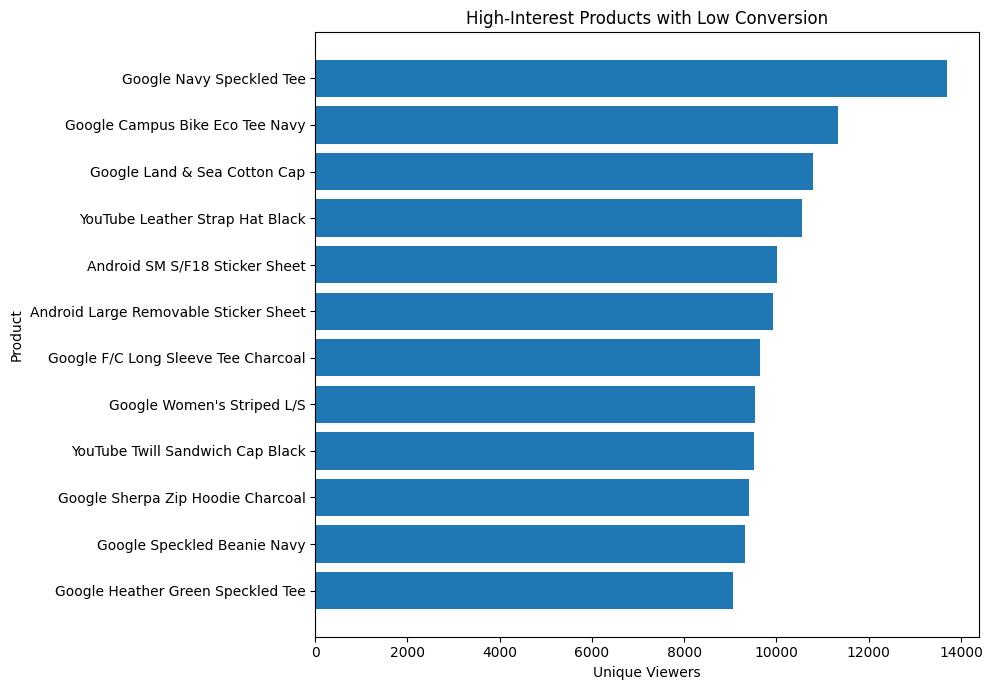

Se detectaron 84 productos bajo los criterios de anomalía y 10 de ellos registran 0 compradores.

Ejemplos con 0 compradores:


,item_name,viewers,cart_users,avg_price,view_to_cart_rate,conversion_rate
6,Google F/C Long Sleeve Tee Charcoal,9640,2548,29.95,26.43,0.0
7,Google Women's Striped L/S,9541,3027,28.98,31.73,0.0
13,Google F/C Long Sleeve Tee Ash,8184,2431,29.97,29.70,0.0
18,Google Eco Tee Black,7683,1826,21.94,23.77,0.0
37,Google Land & Sea Unisex Tee,5696,1161,24.91,20.38,0.0
58,Google Black Tee,3168,692,19.54,21.84,0.0
59,Google Pocket Tee Grey,3107,807,28.06,25.97,0.0
60,Google Cloud Unisex Zip Hoodie,3087,869,68.99,28.15,0.0
61,Google Unisex Pride Eco-Tee Black,3018,624,21.89,20.68,0.0
78,Google Tee Dark Blue,1528,375,23.27,24.54,0.0


In [ ]:
products_ranked = products.sort_values(
    ["viewers", "view_to_cart_rate"],
    ascending=[False, False],
).copy()

display(products_ranked.head(15))

top_anomalies = products_ranked.head(12).sort_values("viewers")

plt.figure(figsize=(10, 7))
plt.barh(top_anomalies["item_name"], top_anomalies["viewers"])
plt.title("High-Interest Products with Low Conversion")
plt.xlabel("Unique Viewers")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

zero_buyers = products_ranked[products_ranked["buyers"] == 0]
print(
    f"Se detectaron {len(products_ranked)} productos bajo los criterios de anomalía "
    f"y {len(zero_buyers)} de ellos registran 0 compradores."
)

if not zero_buyers.empty:
    print("\nEjemplos con 0 compradores:")
    display(
        zero_buyers[
            [
                "item_name",
                "viewers",
                "cart_users",
                "avg_price",
                "view_to_cart_rate",
                "conversion_rate",
            ]
        ].head(10)
    )

**Interpretación:** un patrón de muchas visualizaciones y carritos con pocas compras justifica investigación adicional sobre disponibilidad, variantes, precio, instrumentación de analytics o fricción posterior al carrito. Los datos agregados no permiten atribuir una causa específica.

## 6. Retención por día

Se observa qué proporción de usuarios vuelve exactamente en D1, D7, D14 y D30 después de su primera actividad.

,days_since_first,retained_users,retention_rate
0,0,270154,100.00
1,1,12538,4.64
2,7,1966,0.73
3,14,934,0.35
4,30,322,0.12


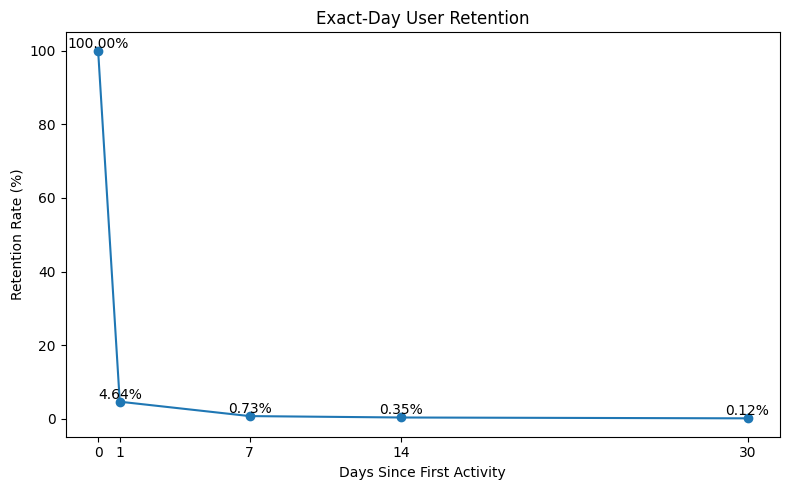

Insight: la retención exacta en D1 es 4.64%.


In [ ]:
retention_sorted = retention.sort_values("days_since_first").copy()
display(retention_sorted)

plt.figure(figsize=(8, 5))
plt.plot(
    retention_sorted["days_since_first"],
    retention_sorted["retention_rate"],
    marker="o",
)
plt.title("Exact-Day User Retention")
plt.xlabel("Days Since First Activity")
plt.ylabel("Retention Rate (%)")
plt.xticks(retention_sorted["days_since_first"])

for x, y in zip(
    retention_sorted["days_since_first"],
    retention_sorted["retention_rate"],
):
    plt.text(x, y, f"{y:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

d1 = retention_sorted.loc[
    retention_sorted["days_since_first"] == 1, "retention_rate"
]
if not d1.empty:
    print(f"Insight: la retención exacta en D1 es {d1.iloc[0]:.2f}%.")

**Nota:** estas tasas representan retorno **exactamente** en cada día indicado. Además, D30 puede estar afectado por censura temporal porque los usuarios adquiridos al final del periodo no disponen de 30 días completos de observación.

## 7. Análisis de cohortes

Se agrupan los usuarios por el mes de su primera actividad y se mide qué porcentaje vuelve en los meses posteriores.

,cohort_month,month_number,cohort_users,retained_users,retention_rate
0,2020-11-01,0,79421,79421,100.00
1,2020-11-01,1,79421,4651,5.86
2,2020-11-01,2,79421,1204,1.52
3,2020-12-01,0,99664,99664,100.00
4,2020-12-01,1,99664,2517,2.53
5,2021-01-01,0,91069,91069,100.00


month_number,0,1,2
cohort_month,,,
2020-11,100.0,5.86,1.52
2020-12,100.0,2.53,NaN
2021-01,100.0,NaN,NaN


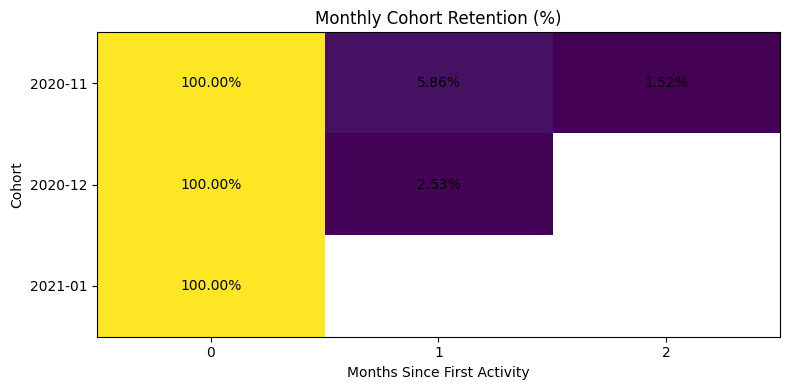

In [ ]:
cohorts = cohorts.copy()
cohorts["cohort_month"] = pd.to_datetime(cohorts["cohort_month"])

display(cohorts)

cohort_matrix = cohorts.pivot(
    index="cohort_month",
    columns="month_number",
    values="retention_rate",
)

cohort_matrix.index = cohort_matrix.index.strftime("%Y-%m")
display(cohort_matrix)

fig, ax = plt.subplots(figsize=(8, 4))
matrix_values = cohort_matrix.to_numpy(dtype=float)
masked = np.ma.masked_invalid(matrix_values)

image = ax.imshow(masked, aspect="auto")

ax.set_title("Monthly Cohort Retention (%)")
ax.set_xlabel("Months Since First Activity")
ax.set_ylabel("Cohort")
ax.set_xticks(range(len(cohort_matrix.columns)))
ax.set_xticklabels(cohort_matrix.columns)
ax.set_yticks(range(len(cohort_matrix.index)))
ax.set_yticklabels(cohort_matrix.index)

for i in range(matrix_values.shape[0]):
    for j in range(matrix_values.shape[1]):
        value = matrix_values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.2f}%", ha="center", va="center")

fig.tight_layout()
plt.show()

In [ ]:
future_months = cohorts[cohorts["month_number"] > 0].copy()

if not future_months.empty:
    best_retention = future_months.loc[future_months["retention_rate"].idxmax()]
    print(
        "Insight: la mayor retención posterior al mes inicial corresponde a la cohorte "
        f"{best_retention['cohort_month']:%Y-%m}, en M{int(best_retention['month_number'])}, "
        f"con {best_retention['retention_rate']:.2f}%."
    )

Insight: la mayor retención posterior al mes inicial corresponde a la cohorte 2020-11, en M1, con 5.86%.


## 8. Hallazgos principales

Las siguientes celdas resumen automáticamente los resultados más relevantes obtenidos en los CSV.

In [ ]:
overall = float(funnel.loc[0, "overall_conversion_rate"])
largest = funnel_metrics.loc[funnel_metrics["dropoff_rate"].idxmax()]

best_device = devices.loc[devices["overall_conversion_rate"].idxmax()]
highest_volume = traffic.loc[traffic["view_item_users"].idxmax()]

print("HALLAZGOS PRINCIPALES")
print("-" * 70)
print(f"1. Conversión general View → Purchase: {overall:.2f}%.")
print(
    f"2. Mayor drop-off: {largest['stage']} "
    f"({largest['dropoff_rate']:.2f}%)."
)
print(
    f"3. Mejor conversión por dispositivo: "
    f"{best_device['device_category']} "
    f"({best_device['overall_conversion_rate']:.2f}%)."
)
print(
    f"4. Mayor fuente de tráfico: {highest_volume['source_name']} "
    f"({highest_volume['view_item_users']:,.0f} viewers; "
    f"{highest_volume['overall_conversion_rate']:.2f}% conversión)."
)
print(
    f"5. Productos detectados bajo criterios de anomalía: {len(products_ranked)}."
)

HALLAZGOS PRINCIPALES
----------------------------------------------------------------------
1. Conversión general View → Purchase: 13.81%.
2. Mayor drop-off: View → Cart (72.60%).
3. Mejor conversión por dispositivo: mobile (7.46%).
4. Mayor fuente de tráfico: google (25,105 viewers; 5.48% conversión).
5. Productos detectados bajo criterios de anomalía: 84.


## 9. Recomendaciones

A partir de los patrones observados, las siguientes acciones son candidatas para investigación y validación:

1. **Investigar la etapa Product View → Add to Cart**, donde se concentra la mayor pérdida del funnel.
2. **Revisar Checkout → Purchase** mediante análisis de errores, disponibilidad, costos inesperados y pruebas de usabilidad.
3. **Analizar productos con alto View → Cart y baja compra**, priorizando aquellos con cero compradores registrados.
4. **Comparar calidad de tráfico por canal**, no solo volumen de adquisición.
5. **Profundizar el análisis de retención** con una ventana temporal más extensa y métricas de retorno acumulado.
6. **Diseñar experimentos o pruebas A/B** antes de atribuir causalidad a cambios de UX.

## 10. Limitaciones

- El dataset está anonimizado/obfuscado y cubre un periodo limitado.
- Las métricas utilizadas fueron agregadas previamente en BigQuery.
- El funnel inicial se basa en usuarios únicos por evento y no valida secuencia estricta dentro de una misma sesión.
- No se dispone de información suficiente para afirmar la causa de los abandonos.
- Las tasas de retención de horizontes largos pueden sufrir censura temporal.
- Los resultados identifican patrones y oportunidades de investigación; no demuestran causalidad.

## Conclusión

El análisis identifica dos áreas prioritarias: **la transición desde la visualización del producto hacia el carrito** y **la finalización del checkout**.

También se observan diferencias entre fuentes de tráfico, productos con fuerte interés pero baja conversión y una retención posterior reducida. Estos patrones pueden utilizarse como punto de partida para investigaciones de UX, análisis de producto y experimentación controlada.